# **1. Perkenalan Dataset**





Dataset yang digunakan dalam proyek ini adalah **Telco Customer Churn**, yaitu dataset yang berisi informasi pelanggan perusahaan telekomunikasi untuk memprediksi kemungkinan pelanggan berhenti menggunakan layanan (churn). Dataset terdiri dari **7.043 data pelanggan dan 21 kolom**, yang mencakup informasi demografis, layanan yang digunakan, informasi kontrak, metode pembayaran, serta biaya layanan.

**Sumber Dataset:**

Dataset diperoleh dari public repository GitHub yang menyediakan dataset Telco Customer Churn dalam format CSV.

**Link Sumber:**
[Telco-Customer-Churn](https://github.com/Nas-virat/Telco-Customer-Churn)

**Variabel Target:**

Churn, dengan dua kelas:
- Yes = Pelanggan mengalami churn
- No = Pelanggan tidak mengalami churn

**Fitur yang digunakan antara lain:**

gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, InternetService, OnlineSecurity, TechSupport, Contract, PaymentMethod, MonthlyCharges, dan TotalCharges.

Dataset ini dipilih karena memiliki kombinasi fitur numerik dan kategorikal serta sesuai untuk permasalahan **Supervised Learning - Binary Classification**. Dataset juga memungkinkan penerapan preprocessing, eksperimen model, hyperparameter tuning, serta implementasi pipeline MLOps pada tahap berikutnya.

# **2. Import Library**

Pada tahap ini, beberapa library Python digunakan untuk proses eksplorasi data, preprocessing, pembangunan model machine learning, evaluasi, serta pencatatan eksperimen.

In [ ]:
# Manipulasi dan analisis data
import pandas as pd
import numpy as np

# Visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Model Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluasi model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
    )

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Menghilangkan warning yang tidak diperlukan
import warnings
warnings.filterwarnings("ignore")

# **3. Memuat Dataset**

Dataset dimuat secara langsung dari repository GitHub menggunakan URL raw sehingga tidak perlu mengunduh dataset secara manual.

In [ ]:
# URL dataset dari GitHub
url = "https://raw.githubusercontent.com/Nas-virat/Telco-Customer-Churn/main/Telco-Customer-Churn.csv"

# Memuat dataset
df = pd.read_csv(url)

# Menampilkan 5 data pertama
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Selanjutnya, dilakukan pemeriksaan ukuran dataset dan informasi setiap kolom.

In [ ]:
# Menampilkan ukuran dataset
print("Ukuran dataset:", df.shape)

# Menampilkan informasi dataset
df.info()

# Menampilkan nama kolom
print("Nama kolom:")
print(df.columns.tolist())

Ukuran dataset: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBillin

# **4. Exploratory Data Analysis (EDA)**

Tahap EDA dilakukan untuk memahami karakteristik dataset, memeriksa kualitas data, serta mengidentifikasi permasalahan yang perlu ditangani pada tahap preprocessing.

Jumlah baris   : 7043
Jumlah kolom   : 21

Tipe data:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

STATISTIK DESKRIPTIF


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



MISSING VALUE
Series([], dtype: int64)

Nilai kosong berupa string/spasi:
{'TotalCharges': np.int64(11)}

DATA DUPLIKAT
Jumlah data duplikat: 0

DISTRIBUSI TARGET - CHURN
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


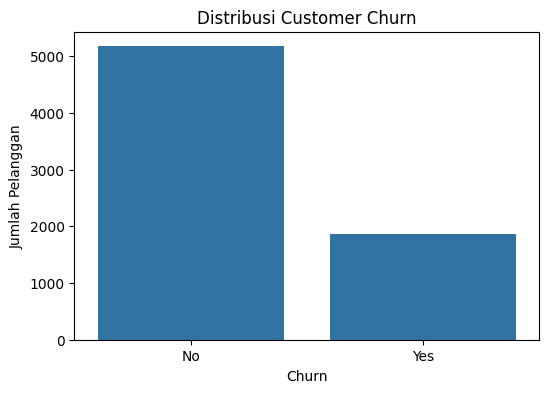

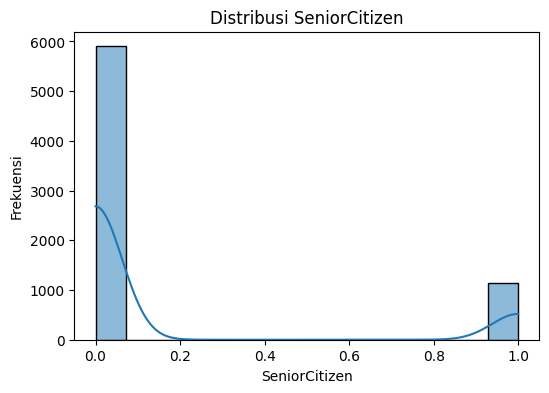

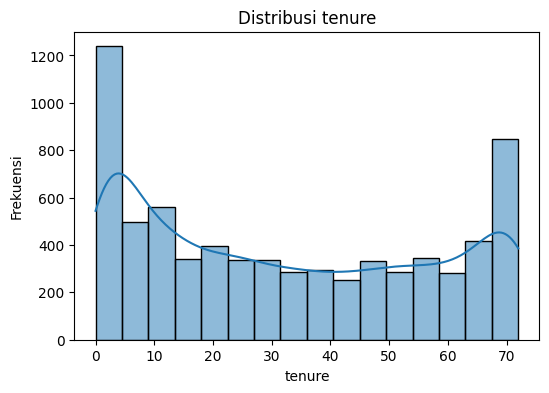

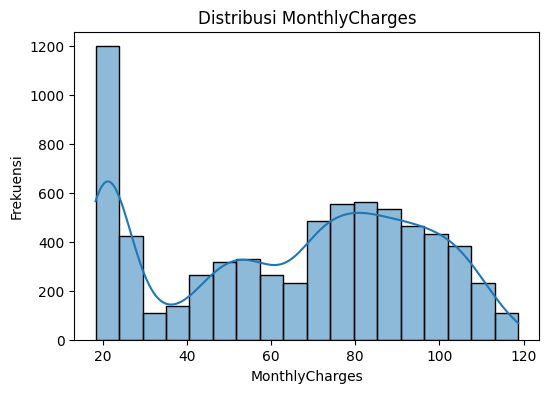

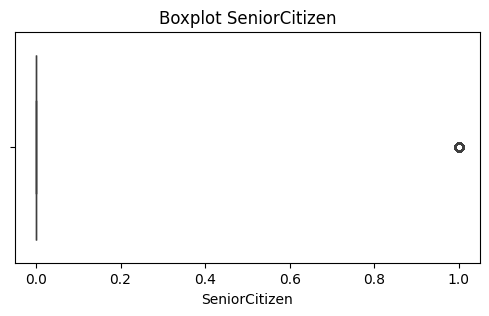

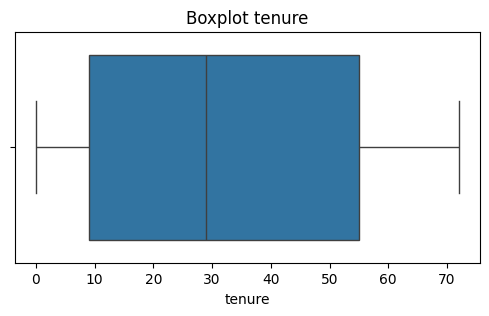

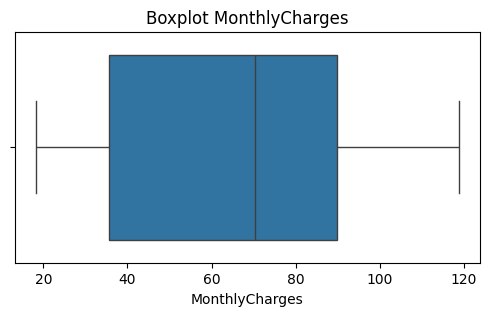

In [ ]:
# Informasi dataset
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print("\nTipe data:")
print(df.dtypes)

# Statistik deskriptif
print("\n" + "=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
display(df.describe())

# Missing value
print("\n" + "=" * 50)
print("MISSING VALUE")
print("=" * 50)

missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Cek nilai kosong berupa string/spasi
print("\nNilai kosong berupa string/spasi:")

empty_values = {}

for col in df.select_dtypes(include="object").columns:
    count = (df[col].astype(str).str.strip() == "").sum()
    if count > 0:
        empty_values[col] = count

if empty_values:
    print(empty_values)
else:
    print("Tidak ditemukan.")

# Data duplikat
print("\n" + "=" * 50)
print("DATA DUPLIKAT")
print("=" * 50)
print("Jumlah data duplikat:", df.duplicated().sum())

# Distribusi target
print("\n" + "=" * 50)
print("DISTRIBUSI TARGET - CHURN")
print("=" * 50)

print(df["Churn"].value_counts())

print("\nPersentase:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

# Visualisasi target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Distribusi Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")
plt.show()

# Fitur numerik
numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges"
]

# Histogram
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.show()

# Boxplot
for col in numeric_columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot {col}")
    plt.xlabel(col)
    plt.show()

# **5. Data Preprocessing**

Pada tahap ini dilakukan proses preprocessing untuk mempersiapkan data sebelum digunakan dalam pemodelan machine learning. Tahapan yang dilakukan meliputi penanganan nilai kosong, pemeriksaan data duplikat, konversi tipe data, pemisahan fitur dan target, encoding data kategorikal, serta standardisasi fitur numerik.

Proses preprocessing diterapkan menggunakan Pipeline dan ColumnTransformer agar setiap tahapan dapat dilakukan secara otomatis dan konsisten pada data training maupun data testing.

In [ ]:
# Membuat salinan dataset
data = df.copy()

# 1. Pemeriksaan data duplikat
duplicate_count = data.duplicated().sum()

print("=" * 50)
print("PEMERIKSAAN DATA DUPLIKAT")
print("=" * 50)
print("Jumlah data duplikat:", duplicate_count)

# Menghapus duplikat jika ditemukan
if duplicate_count > 0:
    data = data.drop_duplicates().reset_index(drop=True)
    print("Data duplikat telah dihapus.")
else:
    print("Tidak terdapat data duplikat.")

# 2. Konversi TotalCharges menjadi numerik
# Nilai kosong/spasi akan dikonversi menjadi NaN
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

print("\n" + "=" * 50)
print("KONVERSI TIPE DATA")
print("=" * 50)
print("Tipe data TotalCharges:", data["TotalCharges"].dtype)

# 3. Pemeriksaan missing value
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("\n" + "=" * 50)
print("MISSING VALUE")
print("=" * 50)

if len(missing_values) > 0:
    print(missing_values)
else:
    print("Tidak terdapat missing value.")

# 4. Mengubah target Churn menjadi numerik
data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

# 5. Memisahkan fitur dan target
# customerID tidak digunakan karena hanya
# merupakan identitas unik pelanggan
X = data.drop(columns=["Churn", "customerID"])
y = data["Churn"]

print("\n" + "=" * 50)
print("PEMISAHAN FITUR DAN TARGET")
print("=" * 50)
print("Jumlah fitur :", X.shape[1])
print("Jumlah data  :", X.shape[0])
print("Target       : Churn")

# 6. Menentukan fitur numerik dan kategorikal
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

print("\nFitur numerik:")
print(numeric_features)

print("\nJumlah fitur kategorikal:", len(categorical_features))

# 7. Pemeriksaan outlier
print("\n" + "=" * 50)
print("PEMERIKSAAN OUTLIER")
print("=" * 50)

for col in numeric_features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (X[col] < lower_bound) |
        (X[col] > upper_bound)
    ).sum()

    print(f"{col}: {outlier_count} outlier")

print("\nOutlier tidak langsung dihapus karena nilai ekstrem")
print("masih dapat merepresentasikan kondisi pelanggan yang valid.")

# 8. Membuat preprocessing pipeline

# Pipeline untuk fitur numerik
numeric_transformer = Pipeline(
    steps=[
        # Mengisi missing value dengan median
        ("imputer", SimpleImputer(strategy="median")),

        # Standardisasi fitur numerik
        ("scaler", StandardScaler())
    ]
)

# Pipeline untuk fitur kategorikal
categorical_transformer = Pipeline(
    steps=[
        # Mengisi missing value dengan nilai yang paling sering muncul
        ("imputer", SimpleImputer(strategy="most_frequent")),

        # Mengubah kategori menjadi fitur numerik
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Menggabungkan preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# 9. Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 50)
print("PEMBAGIAN DATA")
print("=" * 50)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# 10. Menjalankan preprocessing
# Fit hanya pada data training
X_train_processed = preprocessor.fit_transform(X_train)

# Transform data testing menggunakan preprocessing
# yang sudah dipelajari dari data training
X_test_processed = preprocessor.transform(X_test)

print("\n" + "=" * 50)
print("HASIL PREPROCESSING")
print("=" * 50)
print("X_train sebelum preprocessing :", X_train.shape)
print("X_train setelah preprocessing:", X_train_processed.shape)

print("\nX_test sebelum preprocessing  :", X_test.shape)
print("X_test setelah preprocessing :", X_test_processed.shape)

# 11. Pemeriksaan hasil akhir
print("\n" + "=" * 50)
print("PEMERIKSAAN HASIL AKHIR")
print("=" * 50)

print(
    "Missing value X_train:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing value X_test :",
    np.isnan(X_test_processed).sum()
)

print(
    "Jumlah kelas target:",
    y.nunique()
)

print("\nPreprocessing selesai.")

PEMERIKSAAN DATA DUPLIKAT
Jumlah data duplikat: 0
Tidak terdapat data duplikat.

KONVERSI TIPE DATA
Tipe data TotalCharges: float64

MISSING VALUE
TotalCharges    11
dtype: int64

PEMISAHAN FITUR DAN TARGET
Jumlah fitur : 19
Jumlah data  : 7043
Target       : Churn

Fitur numerik:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Jumlah fitur kategorikal: 15

PEMERIKSAAN OUTLIER
SeniorCitizen: 1142 outlier
tenure: 0 outlier
MonthlyCharges: 0 outlier
TotalCharges: 0 outlier

Outlier tidak langsung dihapus karena nilai ekstrem
masih dapat merepresentasikan kondisi pelanggan yang valid.

PEMBAGIAN DATA
X_train: (5634, 19)
X_test : (1409, 19)
y_train: (5634,)
y_test : (1409,)

HASIL PREPROCESSING
X_train sebelum preprocessing : (5634, 19)
X_train setelah preprocessing: (5634, 45)

X_test sebelum preprocessing  : (1409, 19)
X_test setelah preprocessing : (1409, 45)

PEMERIKSAAN HASIL AKHIR
Missing value X_train: 0
Missing value X_test : 0
Jumlah kelas target: 2

Preprocessing s

# **6. Eksperimen Model**

Pada tahap ini dilakukan eksperimen menggunakan beberapa algoritma klasifikasi untuk menentukan model yang memberikan performa terbaik dalam memprediksi customer churn.

Model yang digunakan adalah Logistic Regression, Random Forest, dan Gradient Boosting. Setiap model menggunakan preprocessing yang sama melalui Pipeline sehingga proses transformasi data dilakukan secara konsisten.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Membuat beberapa model

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}

# Menyimpan hasil eksperimen
experiment_results = []

# 2. Eksperimen setiap model

for model_name, model in models.items():

    print("=" * 60)
    print(f"MODEL: {model_name}")
    print("=" * 60)

    # Pipeline:
    # preprocessing -> model
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Training
    model_pipeline.fit(X_train, y_train)

    # Prediksi
    y_pred = model_pipeline.predict(X_test)

    # Probabilitas untuk ROC-AUC
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]

    # Evaluasi
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Menyimpan hasil
    experiment_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    # Menampilkan hasil
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

# 3. Membuat tabel perbandingan

results_df = pd.DataFrame(experiment_results)

print("\n" + "=" * 60)
print("PERBANDINGAN HASIL EKSPERIMEN")
print("=" * 60)

display(
    results_df.sort_values(
        by="F1-Score",
        ascending=False
    ).reset_index(drop=True)
)

# 4. Menentukan model terbaik

best_model_name = (
    results_df
    .sort_values(by="F1-Score", ascending=False)
    .iloc[0]["Model"]
)

best_f1 = (
    results_df
    .sort_values(by="F1-Score", ascending=False)
    .iloc[0]["F1-Score"]
)

print("\nModel terbaik berdasarkan F1-Score:")
print(best_model_name)
print(f"F1-Score: {best_f1:.4f}")

MODEL: Logistic Regression
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-Score : 0.6040
ROC-AUC  : 0.8419
MODEL: Random Forest
Accuracy : 0.7757
Precision: 0.6000
Recall   : 0.4652
F1-Score : 0.5241
ROC-AUC  : 0.8186
MODEL: Gradient Boosting
Accuracy : 0.8062
Precision: 0.6735
Recall   : 0.5241
F1-Score : 0.5895
ROC-AUC  : 0.8434

PERBANDINGAN HASIL EKSPERIMEN


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843362
2,Random Forest,0.775727,0.600000,0.465241,0.524096,0.818593



Model terbaik berdasarkan F1-Score:
Logistic Regression
F1-Score: 0.6040


## Hyperparameter Tuning

Setelah membandingkan beberapa model, Logistic Regression dipilih sebagai model terbaik berdasarkan nilai F1-Score. Selanjutnya dilakukan hyperparameter tuning menggunakan GridSearchCV untuk memperoleh kombinasi parameter yang dapat meningkatkan performa model.

Proses tuning tetap menggunakan Pipeline agar preprocessing dan pemodelan dilakukan secara konsisten serta mencegah data leakage.

In [ ]:
# Pipeline preprocessing + Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Parameter yang akan diuji
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Training dan pencarian parameter terbaik
grid_search.fit(X_train, y_train)

# Parameter terbaik
print("\n" + "=" * 60)
print("HASIL HYPERPARAMETER TUNING")
print("=" * 60)

print("Parameter terbaik:")
print(grid_search.best_params_)

print(f"\nF1-Score cross-validation terbaik: {grid_search.best_score_:.4f}")

# Model terbaik hasil tuning
tuned_model = grid_search.best_estimator_

# Prediksi data testing
y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

# Evaluasi
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_roc_auc = roc_auc_score(
    y_test,
    y_prob_tuned
)

print("\nPerforma model setelah tuning:")
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["No Churn", "Churn"]
    )
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

HASIL HYPERPARAMETER TUNING
Parameter terbaik:
{'model__C': 100, 'model__solver': 'liblinear'}

F1-Score cross-validation terbaik: 0.5989

Performa model setelah tuning:
Accuracy : 0.8006
Precision: 0.6467
Recall   : 0.5481
F1-Score : 0.5933
ROC-AUC  : 0.8407

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



# **7. MLflow Eksperiment Tracking**

In [ ]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import mlflow
import mlflow.sklearn

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


MLflow digunakan untuk mencatat dan membandingkan hasil eksperimen machine learning secara terstruktur. Parameter, metrik evaluasi, model, dan artifact hasil eksperimen akan dicatat pada setiap run untuk mendukung proses reproduksi dan evaluasi model.

In [ ]:
# Nama experiment
experiment_name = "Telco Customer Churn Classification"

# Membuat atau menggunakan experiment
mlflow.set_experiment(experiment_name)

print("Experiment:", experiment_name)
print("MLflow version:", mlflow.__version__)

2026/09/15 17:06:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/15 17:06:38 INFO mlflow.store.db.utils: Updating database tables
2026/09/15 17:06:43 INFO mlflow.tracking.fluent: Experiment with name 'Telco Customer Churn Classification' does not exist. Creating a new experiment.


Experiment: Telco Customer Churn Classification
MLflow version: 3.16.0


In [ ]:
import subprocess
import sys

# Menjalankan MLflow server di background tunggu sampai 20 detik untuk langkah selanjutnya
mlflow_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "mlflow",
        "server",
        "--host",
        "0.0.0.0",
        "--port",
        "5000"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print("MLflow server sedang dijalankan.")
print("PID:", mlflow_process.pid)

MLflow server sedang dijalankan.
PID: 7067


In [ ]:
import requests

response = requests.get("http://127.0.0.1:5000", timeout=10)

print("Status:", response.status_code)

if response.status_code == 200:
    print("MLflow server berhasil berjalan.")

Status: 200
MLflow server berhasil berjalan.


In [ ]:
import mlflow

# Mengatur tracking URI ke MLflow server lokal
mlflow.set_tracking_uri("http://127.0.0.1:5000")

print("MLflow Tracking URI:")
print(mlflow.get_tracking_uri())


MLflow Tracking URI:
http://127.0.0.1:5000


In [ ]:
with mlflow.start_run(run_name="Test MLflow Connection"):

    # Logging parameter
    mlflow.log_param(
        "test_parameter",
        "connection_success"
    )

    # Logging metric
    mlflow.log_metric(
        "test_metric",
        1.0
    )

    # Mengambil Run ID
    run_id = mlflow.active_run().info.run_id

print("MLflow berhasil terhubung.")
print("Run ID:", run_id)

🏃 View run Test MLflow Connection at: http://127.0.0.1:5000/#/experiments/1/runs/684dbf3ca8d44562a70d5a0dfeabad81
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
MLflow berhasil terhubung.
Run ID: 684dbf3ca8d44562a70d5a0dfeabad81


Pada tahap ini dilakukan pencatatan eksperimen machine learning menggunakan MLflow. Setiap eksperimen akan mencatat parameter, metrik evaluasi, classification report, dan model yang dihasilkan sehingga proses eksperimen dapat dilacak dan dibandingkan secara sistematis.

Eksperimen dilakukan menggunakan tiga algoritma klasifikasi, yaitu Logistic Regression, Random Forest, dan Gradient Boosting. Hasil hyperparameter tuning pada Logistic Regression juga dicatat sebagai eksperimen terpisah.

In [ ]:
import mlflow
import mlflow.sklearn

# Menggunakan experiment yang sama
experiment_name = "Telco Customer Churn Classification"

mlflow.set_experiment(experiment_name)

print("Experiment:", experiment_name)
print("Tracking URI:", mlflow.get_tracking_uri())


# ==========================================
# Fungsi logging metric
# ==========================================

def log_classification_metrics(y_true, y_pred, y_prob):

    mlflow.log_metric(
        "accuracy",
        accuracy_score(y_true, y_pred)
    )

    mlflow.log_metric(
        "precision",
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    mlflow.log_metric(
        "recall",
        recall_score(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    mlflow.log_metric(
        "f1_score",
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    mlflow.log_metric(
        "roc_auc",
        roc_auc_score(
            y_true,
            y_prob
        )
    )


# ==========================================
# Menyimpan informasi Run
# ==========================================

mlflow_runs = []


# ==========================================
# Eksperimen:
# Logistic Regression
# Random Forest
# Gradient Boosting
# ==========================================

for model_name, model in models.items():

    print("\n" + "=" * 60)
    print(f"MLFLOW RUN: {model_name}")
    print("=" * 60)

    with mlflow.start_run(
        run_name=f"{model_name} Experiment"
    ):

        # ----------------------------------
        # Membuat Pipeline
        # ----------------------------------

        model_pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        # ----------------------------------
        # Training
        # ----------------------------------

        model_pipeline.fit(
            X_train,
            y_train
        )

        # ----------------------------------
        # Prediction
        # ----------------------------------

        y_pred = model_pipeline.predict(
            X_test
        )

        y_prob = model_pipeline.predict_proba(
            X_test
        )[:, 1]

        # ----------------------------------
        # Logging parameter umum
        # ----------------------------------

        mlflow.log_param(
            "model_name",
            model_name
        )

        mlflow.log_param(
            "test_size",
            0.2
        )

        mlflow.log_param(
            "random_state",
            42
        )

        mlflow.log_param(
            "training_samples",
            X_train.shape[0]
        )

        mlflow.log_param(
            "test_samples",
            X_test.shape[0]
        )

        mlflow.log_param(
            "number_of_features",
            X_train.shape[1]
        )

        # ----------------------------------
        # Logging parameter model
        # ----------------------------------

        model_params = model.get_params()

        for param_name, param_value in model_params.items():

            if (
                isinstance(
                    param_value,
                    (str, int, float, bool)
                )
                or param_value is None
            ):

                mlflow.log_param(
                    param_name,
                    str(param_value)
                )

        # ----------------------------------
        # Logging metrics
        # ----------------------------------

        log_classification_metrics(
            y_test,
            y_pred,
            y_prob
        )

        # ----------------------------------
        # Classification report
        # ----------------------------------

        report = classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Churn",
                "Churn"
            ]
        )

        report_path = (
            f"/tmp/"
            f"{model_name.replace(' ', '_')}"
            f"_classification_report.txt"
        )

        with open(
            report_path,
            "w"
        ) as file:

            file.write(report)

        mlflow.log_artifact(
            report_path,
            artifact_path="evaluation"
        )

        # ----------------------------------
        # Logging model
        # Menggunakan cloudpickle
        # ----------------------------------

        mlflow.sklearn.log_model(
            model_pipeline,
            name="model",
            serialization_format="cloudpickle"
        )

        # ----------------------------------
        # Menyimpan Run ID
        # ----------------------------------

        current_run_id = (
            mlflow.active_run()
            .info
            .run_id
        )

        mlflow_runs.append({
            "Model": model_name,
            "Run_ID": current_run_id
        })

        print("Run ID:", current_run_id)


# ==========================================
# Eksperimen 4:
# Logistic Regression Tuned
# ==========================================

print("\n" + "=" * 60)
print("MLFLOW RUN: Logistic Regression Tuned")
print("=" * 60)

with mlflow.start_run(
    run_name="Logistic Regression Tuned Experiment"
):

    # ----------------------------------
    # Logging parameter tuning
    # ----------------------------------

    mlflow.log_param(
        "model_name",
        "Logistic Regression Tuned"
    )

    mlflow.log_param(
        "best_C",
        grid_search.best_params_[
            "model__C"
        ]
    )

    mlflow.log_param(
        "best_solver",
        grid_search.best_params_[
            "model__solver"
        ]
    )

    mlflow.log_param(
        "cv",
        5
    )

    mlflow.log_param(
        "scoring",
        "f1"
    )

    mlflow.log_param(
        "test_size",
        0.2
    )

    mlflow.log_param(
        "random_state",
        42
    )

    # ----------------------------------
    # Logging metrics
    # ----------------------------------

    log_classification_metrics(
        y_test,
        y_pred_tuned,
        y_prob_tuned
    )

    mlflow.log_metric(
        "cv_best_f1",
        grid_search.best_score_
    )

    # ----------------------------------
    # Classification report
    # ----------------------------------

    tuned_report = classification_report(
        y_test,
        y_pred_tuned,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )

    tuned_report_path = (
        "/tmp/"
        "Logistic_Regression_Tuned_"
        "classification_report.txt"
    )

    with open(
        tuned_report_path,
        "w"
    ) as file:

        file.write(tuned_report)

    mlflow.log_artifact(
        tuned_report_path,
        artifact_path="evaluation"
    )

    # ----------------------------------
    # Logging tuned model
    # ----------------------------------

    mlflow.sklearn.log_model(
        tuned_model,
        name="model",
        serialization_format="cloudpickle"
    )

    # ----------------------------------
    # Menyimpan Run ID
    # ----------------------------------

    tuned_run_id = (
        mlflow.active_run()
        .info
        .run_id
    )

    mlflow_runs.append({
        "Model": "Logistic Regression Tuned",
        "Run_ID": tuned_run_id
    })

    print("Run ID:", tuned_run_id)


# ==========================================
# Menampilkan semua Run
# ==========================================

mlflow_runs_df = pd.DataFrame(
    mlflow_runs
)

print("\n" + "=" * 60)
print("DAFTAR MLFLOW RUN")
print("=" * 60)

display(
    mlflow_runs_df
)

print("\nSemua eksperimen berhasil dicatat ke MLflow.")

Experiment: Telco Customer Churn Classification
Tracking URI: http://127.0.0.1:5000

MLFLOW RUN: Logistic Regression


2026/09/15 17:07:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: 4ab345092b7c40b6b1d79c75a319d474
🏃 View run Logistic Regression Experiment at: http://127.0.0.1:5000/#/experiments/1/runs/4ab345092b7c40b6b1d79c75a319d474
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

MLFLOW RUN: Random Forest


2026/09/15 17:08:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: f3ed52cf8a834c7cb16b3c9258fde726
🏃 View run Random Forest Experiment at: http://127.0.0.1:5000/#/experiments/1/runs/f3ed52cf8a834c7cb16b3c9258fde726
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

MLFLOW RUN: Gradient Boosting


...

Run ID: b8fdc5415d4a49a794c4038a8696fd81
🏃 View run Gradient Boosting Experiment at: http://127.0.0.1:5000/#/experiments/1/runs/b8fdc5415d4a49a794c4038a8696fd81
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

MLFLOW RUN: Logistic Regression Tuned


2026/09/15 17:08:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: 26c5a903ba4b4f51ac20b176f824cdba
🏃 View run Logistic Regression Tuned Experiment at: http://127.0.0.1:5000/#/experiments/1/runs/26c5a903ba4b4f51ac20b176f824cdba
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

DAFTAR MLFLOW RUN


,Model,Run_ID
0,Logistic Regression,4ab345092b7c40b6b1d79c75a319d474
1,Random Forest,f3ed52cf8a834c7cb16b3c9258fde726
2,Gradient Boosting,b8fdc5415d4a49a794c4038a8696fd81
3,Logistic Regression Tuned,26c5a903ba4b4f51ac20b176f824cdba



Semua eksperimen berhasil dicatat ke MLflow.


# **8. MLflow Additional Artifacts**

Untuk melengkapi dokumentasi eksperimen, beberapa artifact tambahan dibuat dan dicatat ke MLflow. Artifact yang digunakan meliputi confusion matrix, grafik perbandingan performa model, dan tabel hasil eksperimen dalam format CSV.

Artifact tersebut digunakan untuk membantu proses evaluasi, perbandingan, dan dokumentasi hasil eksperimen machine learning.

HASIL EKSPERIMEN


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.818593
2,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843362
3,Logistic Regression Tuned,0.800568,0.646688,0.548128,0.593343,0.840673



CSV berhasil dibuat:
/tmp/model_comparison_results.csv


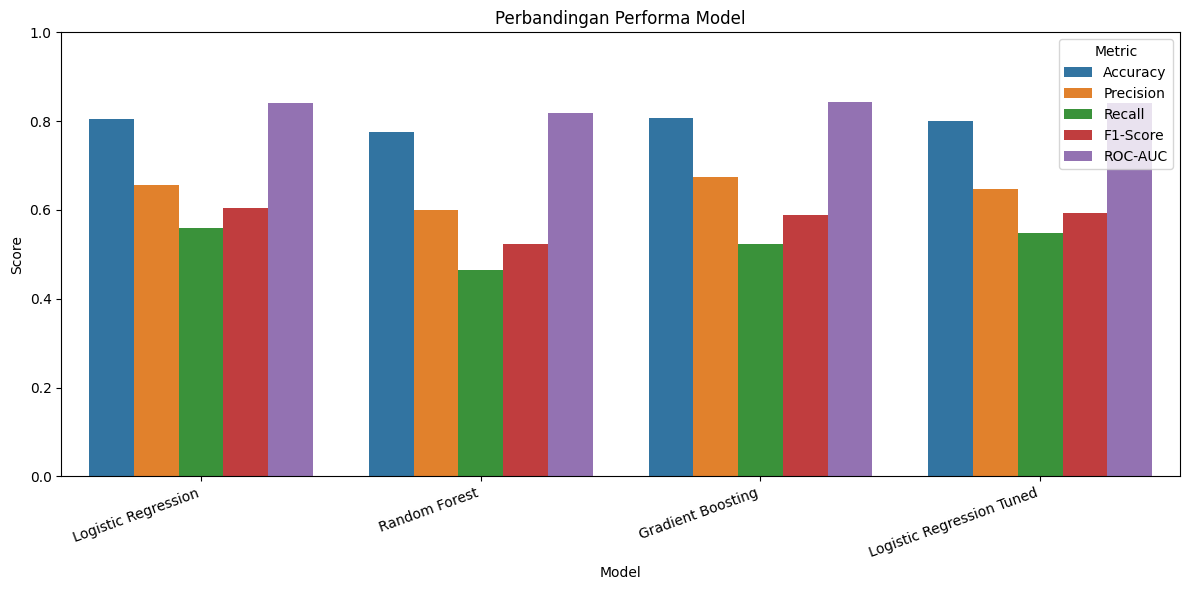

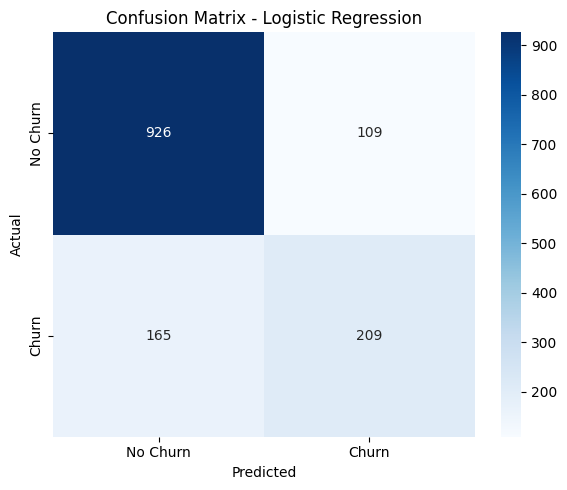

🏃 View run Additional Evaluation Artifacts at: http://127.0.0.1:5000/#/experiments/1/runs/b54eeb38e0c84b728745f8569db358ea
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

ADDITIONAL ARTIFACT BERHASIL DICATAT
Artifact Run ID: b54eeb38e0c84b728745f8569db358ea

Artifact yang dicatat:
- model_comparison_results.csv
- model_performance_comparison.png
- logistic_regression_confusion_matrix.png

Semua additional artifact berhasil dicatat ke MLflow.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import mlflow


# ==========================================
# 1. Membuat DataFrame hasil eksperimen
# ==========================================

artifact_results = results_df.copy()

# Menambahkan hasil tuning
tuned_result = pd.DataFrame([{
    "Model": "Logistic Regression Tuned",
    "Accuracy": tuned_accuracy,
    "Precision": tuned_precision,
    "Recall": tuned_recall,
    "F1-Score": tuned_f1,
    "ROC-AUC": tuned_roc_auc
}])

artifact_results = pd.concat(
    [
        artifact_results,
        tuned_result
    ],
    ignore_index=True
)

print("=" * 60)
print("HASIL EKSPERIMEN")
print("=" * 60)

display(artifact_results)


# ==========================================
# 2. Menyimpan hasil eksperimen sebagai CSV
# ==========================================

results_csv_path = "/tmp/model_comparison_results.csv"

artifact_results.to_csv(
    results_csv_path,
    index=False
)

print("\nCSV berhasil dibuat:")
print(results_csv_path)


# ==========================================
# 3. Membuat grafik perbandingan model
# ==========================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_long = artifact_results.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Perbandingan Performa Model"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()

comparison_plot_path = (
    "/tmp/model_performance_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 4. Confusion Matrix
# ==========================================

# Menggunakan baseline Logistic Regression
# sebagai model terbaik berdasarkan F1-Score

best_model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

best_model_pipeline.fit(
    X_train,
    y_train
)

best_y_pred = best_model_pipeline.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    best_y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

confusion_matrix_path = (
    "/tmp/logistic_regression_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 5. Logging artifact ke MLflow
# ==========================================

with mlflow.start_run(
    run_name="Additional Evaluation Artifacts"
):

    # Logging informasi eksperimen
    mlflow.log_param(
        "artifact_purpose",
        "Model evaluation and comparison"
    )

    mlflow.log_param(
        "best_model",
        "Logistic Regression"
    )

    mlflow.log_param(
        "selection_metric",
        "F1-Score"
    )

    mlflow.log_param(
        "best_f1_score",
        round(
            results_df[
                results_df["Model"] ==
                "Logistic Regression"
            ]["F1-Score"].iloc[0],
            4
        )
    )

    # Logging CSV
    mlflow.log_artifact(
        results_csv_path,
        artifact_path="results"
    )

    # Logging grafik perbandingan
    mlflow.log_artifact(
        comparison_plot_path,
        artifact_path="visualizations"
    )

    # Logging confusion matrix
    mlflow.log_artifact(
        confusion_matrix_path,
        artifact_path="visualizations"
    )

    artifact_run_id = (
        mlflow.active_run()
        .info
        .run_id
    )

print("\n" + "=" * 60)
print("ADDITIONAL ARTIFACT BERHASIL DICATAT")
print("=" * 60)

print("Artifact Run ID:", artifact_run_id)

print("\nArtifact yang dicatat:")
print("- model_comparison_results.csv")
print("- model_performance_comparison.png")
print("- logistic_regression_confusion_matrix.png")

print("\nSemua additional artifact berhasil dicatat ke MLflow.")

# **9. DagsHub MLflow Tracking**

Pada tahap ini MLflow dikonfigurasi untuk menggunakan DagsHub sebagai remote tracking server. DagsHub digunakan untuk menyimpan hasil eksperimen, parameter, metric, artifact, dan model secara terpusat sehingga hasil eksperimen dapat diakses dan didokumentasikan secara online.

In [ ]:
import os
import mlflow
from getpass import getpass

# Informasi repository DagsHub
dagshub_username = "rahmatreyhan05"
dagshub_repository = "telco-customer-churn-mlflow"

# MLflow Tracking URI DagsHub
dagshub_tracking_uri = (
    f"https://dagshub.com/"
    f"{dagshub_username}/"
    f"{dagshub_repository}.mlflow"
)

# Memasukkan token secara aman
dagshub_token = getpass(
    "Masukkan DagsHub Access Token: "
)

# Environment variables untuk authentication
os.environ["MLFLOW_TRACKING_USERNAME"] = dagshub_username
os.environ["MLFLOW_TRACKING_PASSWORD"] = dagshub_token

# Mengarahkan MLflow ke DagsHub
mlflow.set_tracking_uri(
    dagshub_tracking_uri
)

print("=" * 60)
print("DAGSHUB MLFLOW CONFIGURATION")
print("=" * 60)

print("Username       :", dagshub_username)
print("Repository     :", dagshub_repository)
print("Tracking URI   :", mlflow.get_tracking_uri())
print("Authentication : Configured")

Masukkan DagsHub Access Token: ··········
DAGSHUB MLFLOW CONFIGURATION
Username       : rahmatreyhan05
Repository     : telco-customer-churn-mlflow
Tracking URI   : https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow
Authentication : Configured


In [ ]:
# TEST DAGSHUB MLFLOW CONNECTION

import mlflow

# Pastikan menggunakan Tracking URI DagsHub
mlflow.set_tracking_uri(
    "https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow"
)

# Membuat / memilih experiment di DagsHub
experiment_name = "Telco Customer Churn Classification"

mlflow.set_experiment(
    experiment_name
)

print("=" * 60)
print("DAGSHUB MLFLOW CONNECTION")
print("=" * 60)

print("Tracking URI:")
print(mlflow.get_tracking_uri())

print("\nExperiment:")
print(experiment_name)

# Test logging
with mlflow.start_run(
    run_name="DagsHub Connection Test"
):

    mlflow.log_param(
        "connection_test",
        "success"
    )

    mlflow.log_metric(
        "test_metric",
        1.0
    )

    dagshub_test_run_id = (
        mlflow.active_run()
        .info
        .run_id
    )

print("\nDagsHub MLflow berhasil menerima logging.")
print("Run ID:", dagshub_test_run_id)

DAGSHUB MLFLOW CONNECTION
Tracking URI:
https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow

Experiment:
Telco Customer Churn Classification
🏃 View run DagsHub Connection Test at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0/runs/906266427aa744bc8a2004fa1b0afc81
🧪 View experiment at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0

DagsHub MLflow berhasil menerima logging.
Run ID: 906266427aa744bc8a2004fa1b0afc81


# **10. Logging Eksperimen Model ke DagsHub**

Setelah koneksi DagsHub berhasil, eksperimen model dilakukan kembali dengan menggunakan DagsHub sebagai *MLflow Tracking Server*. Empat eksperimen yang dicatat terdiri dari Logistic Regression, Random Forest, Gradient Boosting, dan Logistic Regression hasil *hyperparameter tuning*. Setiap *run* mencatat parameter model, metrik evaluasi, *classification report*, serta model hasil pelatihan sebagai *artifact*.

In [ ]:
# ============================================================
# LOGGING 4 MODEL KE DAGSHUB
# DENGAN EVALUATION ARTIFACT LENGKAP
# ============================================================

import os
import mlflow
import mlflow.sklearn
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. KONFIGURASI DAGSHUB
# ============================================================

dagshub_tracking_uri = (
    "https://dagshub.com/"
    "rahmatreyhan05/"
    "telco-customer-churn-mlflow"
    ".mlflow"
)

mlflow.set_tracking_uri(
    dagshub_tracking_uri
)

experiment_name = (
    "Telco Customer Churn Classification"
)

mlflow.set_experiment(
    experiment_name
)

print("=" * 70)
print("DAGSHUB MLFLOW - MODEL EXPERIMENTS")
print("=" * 70)

print("Tracking URI :", mlflow.get_tracking_uri())
print("Experiment   :", experiment_name)


# ============================================================
# 2. SIAPKAN DATA MENTAH
# ============================================================

X_raw = data.drop(
    columns=["Churn", "customerID"]
)

y_raw = data["Churn"]


# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print("\nData:")
print("X_train :", X_train_raw.shape)
print("X_test  :", X_test_raw.shape)
print("y_train :", y_train_raw.shape)
print("y_test  :", y_test_raw.shape)


# ============================================================
# 4. DEFINISIKAN FITUR
# ============================================================

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    column
    for column in X_raw.columns
    if column not in numeric_features
]


# ============================================================
# 5. FUNGSI MEMBUAT PREPROCESSOR
# ============================================================

def create_preprocessor():

    numeric_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    categorical_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

    return ColumnTransformer([
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ])


# ============================================================
# 6. FUNGSI METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        )
    }


# ============================================================
# 7. FUNGSI NAMA FILE
# ============================================================

def clean_model_name(model_name):

    return (
        model_name
        .lower()
        .replace(" ", "_")
    )


# ============================================================
# 8. FUNGSI MEMBUAT CONFUSION MATRIX
# ============================================================

def save_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    output_path
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    display_labels = [
        "No Churn",
        "Churn"
    ]

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )

    disp.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()


# ============================================================
# 9. DEFINISIKAN MODEL BASELINE
# ============================================================

models_dagshub = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}


# ============================================================
# 10. TEMPAT HASIL
# ============================================================

dagshub_results = []


# ============================================================
# 11. LOGGING 3 MODEL BASELINE
# ============================================================

for model_name, model in models_dagshub.items():

    print("\n" + "=" * 70)
    print(f"LOGGING: {model_name}")
    print("=" * 70)


    # --------------------------------------------------------
    # Nama file
    # --------------------------------------------------------

    file_prefix = clean_model_name(
        model_name
    )


    # --------------------------------------------------------
    # Preprocessor baru
    # --------------------------------------------------------

    model_preprocessor = create_preprocessor()


    # --------------------------------------------------------
    # Pipeline
    # --------------------------------------------------------

    model_pipeline = Pipeline([
        (
            "preprocessor",
            model_preprocessor
        ),
        (
            "model",
            model
        )
    ])


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model_pipeline.fit(
        X_train_raw,
        y_train_raw
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    y_pred = model_pipeline.predict(
        X_test_raw
    )

    y_prob = model_pipeline.predict_proba(
        X_test_raw
    )[:, 1]


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    metrics = calculate_metrics(
        y_test_raw,
        y_pred,
        y_prob
    )


    # --------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------

    report = classification_report(
        y_test_raw,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ],
        zero_division=0
    )


    # ========================================================
    # MLflow Run
    # ========================================================

    with mlflow.start_run(
        run_name=f"DagsHub - {model_name}"
    ) as run:

        # ====================================================
        # PARAMETERS
        # ====================================================

        mlflow.log_param(
            "model_name",
            model_name
        )

        mlflow.log_param(
            "test_size",
            0.2
        )

        mlflow.log_param(
            "random_state",
            42
        )

        mlflow.log_param(
            "preprocessing",
            "Median Imputation + StandardScaler + OneHotEncoder"
        )


        # ====================================================
        # MODEL PARAMETERS
        # ====================================================

        model_params = model.get_params()

        for param_name, param_value in model_params.items():

            if param_value is not None:

                try:

                    mlflow.log_param(
                        f"model_{param_name}",
                        param_value
                    )

                except Exception:

                    pass


        # ====================================================
        # METRICS
        # ====================================================

        mlflow.log_metrics(
            metrics
        )


        # ====================================================
        # FOLDER TEMPORARY
        # ====================================================

        artifact_dir = (
            f"/tmp/"
            f"dagshub_{file_prefix}"
        )

        os.makedirs(
            artifact_dir,
            exist_ok=True
        )


        # ====================================================
        # 1. CLASSIFICATION REPORT
        # ====================================================

        report_path = os.path.join(
            artifact_dir,
            f"{file_prefix}_classification_report.txt"
        )

        with open(
            report_path,
            "w"
        ) as file:

            file.write(
                f"Model: {model_name}\n\n"
            )

            file.write(
                "Evaluation Metrics:\n"
            )

            for metric_name, value in metrics.items():

                file.write(
                    f"{metric_name}: {value:.6f}\n"
                )

            file.write(
                "\nClassification Report:\n"
            )

            file.write(
                report
            )


        # ====================================================
        # LOG REPORT KE evaluation/
        # ====================================================

        mlflow.log_artifact(
            report_path,
            artifact_path="evaluation"
        )


        # ====================================================
        # 2. CONFUSION MATRIX
        # ====================================================

        confusion_matrix_path = os.path.join(
            artifact_dir,
            f"{file_prefix}_confusion_matrix.png"
        )

        save_confusion_matrix(
            y_test_raw,
            y_pred,
            model_name,
            confusion_matrix_path
        )


        # ====================================================
        # LOG CONFUSION MATRIX KE evaluation/
        # ====================================================

        mlflow.log_artifact(
            confusion_matrix_path,
            artifact_path="evaluation"
        )


        # ====================================================
        # 3. METRICS CSV
        # ====================================================

        metrics_df = pd.DataFrame([
            {
                "Model":
                    model_name,

                "Accuracy":
                    metrics["accuracy"],

                "Precision":
                    metrics["precision"],

                "Recall":
                    metrics["recall"],

                "F1-Score":
                    metrics["f1_score"],

                "ROC-AUC":
                    metrics["roc_auc"]
            }
        ])


        metrics_path = os.path.join(
            artifact_dir,
            f"{file_prefix}_metrics.csv"
        )

        metrics_df.to_csv(
            metrics_path,
            index=False
        )


        # ====================================================
        # LOG METRICS CSV KE evaluation/
        # ====================================================

        mlflow.log_artifact(
            metrics_path,
            artifact_path="evaluation"
        )


        # ====================================================
        # 4. MODEL ARTIFACT
        # ====================================================

        mlflow.sklearn.log_model(
            model_pipeline,
            name="model",
            serialization_format="cloudpickle"
        )


        # ====================================================
        # RUN ID
        # ====================================================

        run_id = run.info.run_id


        # ====================================================
        # SIMPAN HASIL
        # ====================================================

        dagshub_results.append({

            "Model":
                model_name,

            "Accuracy":
                metrics["accuracy"],

            "Precision":
                metrics["precision"],

            "Recall":
                metrics["recall"],

            "F1-Score":
                metrics["f1_score"],

            "ROC-AUC":
                metrics["roc_auc"],

            "Run ID":
                run_id
        })


        # ====================================================
        # OUTPUT
        # ====================================================

        print("Run ID    :", run_id)
        print("Accuracy  :", round(metrics["accuracy"], 4))
        print("Precision :", round(metrics["precision"], 4))
        print("Recall    :", round(metrics["recall"], 4))
        print("F1-Score  :", round(metrics["f1_score"], 4))
        print("ROC-AUC   :", round(metrics["roc_auc"], 4))

        print("\nArtifact:")
        print("evaluation/")
        print(
            f"├── {file_prefix}_classification_report.txt"
        )
        print(
            f"├── {file_prefix}_confusion_matrix.png"
        )
        print(
            f"└── {file_prefix}_metrics.csv"
        )
        print("model/")
        print("└── MLflow model")


# ============================================================
# 12. LOGISTIC REGRESSION TUNED
# ============================================================

print("\n" + "=" * 70)
print("LOGGING: Logistic Regression Tuned")
print("=" * 70)


# ============================================================
# PARAMETER TERBAIK DARI GRID SEARCH
# ============================================================

best_C = grid_search.best_params_[
    "model__C"
]

best_solver = grid_search.best_params_[
    "model__solver"
]

best_cv_f1 = grid_search.best_score_


# ============================================================
# NAMA MODEL
# ============================================================

tuned_model_name = (
    "Logistic Regression Tuned"
)

tuned_file_prefix = (
    "logistic_regression_tuned"
)


# ============================================================
# PREPROCESSOR BARU
# ============================================================

tuned_preprocessor = create_preprocessor()


# ============================================================
# MODEL TUNED
# ============================================================

tuned_model_dagshub = LogisticRegression(
    C=best_C,
    solver=best_solver,
    max_iter=1000,
    random_state=42
)


# ============================================================
# PIPELINE
# ============================================================

tuned_pipeline = Pipeline([
    (
        "preprocessor",
        tuned_preprocessor
    ),
    (
        "model",
        tuned_model_dagshub
    )
])


# ============================================================
# TRAINING
# ============================================================

tuned_pipeline.fit(
    X_train_raw,
    y_train_raw
)


# ============================================================
# PREDICTION
# ============================================================

y_pred_tuned = tuned_pipeline.predict(
    X_test_raw
)

y_prob_tuned = tuned_pipeline.predict_proba(
    X_test_raw
)[:, 1]


# ============================================================
# METRICS
# ============================================================

metrics_tuned = calculate_metrics(
    y_test_raw,
    y_pred_tuned,
    y_prob_tuned
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report_tuned = classification_report(
    y_test_raw,
    y_pred_tuned,
    target_names=[
        "No Churn",
        "Churn"
    ],
    zero_division=0
)


# ============================================================
# MLflow Run Tuned
# ============================================================

with mlflow.start_run(
    run_name="DagsHub - Logistic Regression Tuned"
) as run:

    # ========================================================
    # PARAMETERS
    # ========================================================

    mlflow.log_param(
        "model_name",
        tuned_model_name
    )

    mlflow.log_param(
        "best_C",
        best_C
    )

    mlflow.log_param(
        "best_solver",
        best_solver
    )

    mlflow.log_param(
        "cv",
        5
    )

    mlflow.log_param(
        "scoring",
        "f1"
    )

    mlflow.log_param(
        "test_size",
        0.2
    )

    mlflow.log_param(
        "random_state",
        42
    )

    mlflow.log_param(
        "preprocessing",
        "Median Imputation + StandardScaler + OneHotEncoder"
    )


    # ========================================================
    # CV BEST SCORE
    # ========================================================

    mlflow.log_metric(
        "cv_best_f1",
        best_cv_f1
    )


    # ========================================================
    # TEST METRICS
    # ========================================================

    mlflow.log_metrics(
        metrics_tuned
    )


    # ========================================================
    # TEMPORARY DIRECTORY
    # ========================================================

    artifact_dir = (
        "/tmp/"
        "dagshub_logistic_regression_tuned"
    )

    os.makedirs(
        artifact_dir,
        exist_ok=True
    )


    # ========================================================
    # 1. CLASSIFICATION REPORT
    # ========================================================

    report_tuned_path = os.path.join(
        artifact_dir,
        "logistic_regression_tuned_classification_report.txt"
    )

    with open(
        report_tuned_path,
        "w"
    ) as file:

        file.write(
            "Model: Logistic Regression Tuned\n\n"
        )

        file.write(
            "Best Hyperparameters:\n"
        )

        file.write(
            f"C: {best_C}\n"
        )

        file.write(
            f"Solver: {best_solver}\n\n"
        )

        file.write(
            "Cross Validation:\n"
        )

        file.write(
            f"CV: 5\n"
        )

        file.write(
            f"Scoring: f1\n"
        )

        file.write(
            f"CV Best F1: {best_cv_f1:.6f}\n\n"
        )

        file.write(
            "Evaluation Metrics:\n"
        )

        for metric_name, value in metrics_tuned.items():

            file.write(
                f"{metric_name}: {value:.6f}\n"
            )

        file.write(
            "\nClassification Report:\n"
        )

        file.write(
            report_tuned
        )


    # ========================================================
    # LOG REPORT KE evaluation/
    # ========================================================

    mlflow.log_artifact(
        report_tuned_path,
        artifact_path="evaluation"
    )


    # ========================================================
    # 2. CONFUSION MATRIX
    # ========================================================

    confusion_matrix_tuned_path = os.path.join(
        artifact_dir,
        "logistic_regression_tuned_confusion_matrix.png"
    )

    save_confusion_matrix(
        y_test_raw,
        y_pred_tuned,
        tuned_model_name,
        confusion_matrix_tuned_path
    )


    # ========================================================
    # LOG CONFUSION MATRIX KE evaluation/
    # ========================================================

    mlflow.log_artifact(
        confusion_matrix_tuned_path,
        artifact_path="evaluation"
    )


    # ========================================================
    # 3. METRICS CSV
    # ========================================================

    tuned_metrics_df = pd.DataFrame([
        {
            "Model":
                tuned_model_name,

            "Accuracy":
                metrics_tuned["accuracy"],

            "Precision":
                metrics_tuned["precision"],

            "Recall":
                metrics_tuned["recall"],

            "F1-Score":
                metrics_tuned["f1_score"],

            "ROC-AUC":
                metrics_tuned["roc_auc"],

            "CV Best F1":
                best_cv_f1,

            "Best C":
                best_C,

            "Best Solver":
                best_solver
        }
    ])


    tuned_metrics_path = os.path.join(
        artifact_dir,
        "logistic_regression_tuned_metrics.csv"
    )

    tuned_metrics_df.to_csv(
        tuned_metrics_path,
        index=False
    )


    # ========================================================
    # LOG METRICS CSV KE evaluation/
    # ========================================================

    mlflow.log_artifact(
        tuned_metrics_path,
        artifact_path="evaluation"
    )


    # ========================================================
    # 4. MODEL ARTIFACT
    # ========================================================

    mlflow.sklearn.log_model(
        tuned_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )


    # ========================================================
    # RUN ID
    # ========================================================

    tuned_run_id = run.info.run_id


    # ========================================================
    # SIMPAN HASIL
    # ========================================================

    dagshub_results.append({

        "Model":
            tuned_model_name,

        "Accuracy":
            metrics_tuned["accuracy"],

        "Precision":
            metrics_tuned["precision"],

        "Recall":
            metrics_tuned["recall"],

        "F1-Score":
            metrics_tuned["f1_score"],

        "ROC-AUC":
            metrics_tuned["roc_auc"],

        "Run ID":
            tuned_run_id
    })


    # ========================================================
    # OUTPUT
    # ========================================================

    print("Run ID    :", tuned_run_id)
    print("Accuracy  :", round(metrics_tuned["accuracy"], 4))
    print("Precision :", round(metrics_tuned["precision"], 4))
    print("Recall    :", round(metrics_tuned["recall"], 4))
    print("F1-Score  :", round(metrics_tuned["f1_score"], 4))
    print("ROC-AUC   :", round(metrics_tuned["roc_auc"], 4))

    print("\nArtifact:")
    print("evaluation/")
    print(
        "├── logistic_regression_tuned_classification_report.txt"
    )
    print(
        "├── logistic_regression_tuned_confusion_matrix.png"
    )
    print(
        "└── logistic_regression_tuned_metrics.csv"
    )
    print("model/")
    print("└── MLflow model")


# ============================================================
# 13. TAMPILKAN HASIL
# ============================================================

dagshub_results_df = pd.DataFrame(
    dagshub_results
)


print("\n" + "=" * 70)
print("RINGKASAN HASIL EKSPERIMEN DAGSHUB")
print("=" * 70)


display(
    dagshub_results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC"
        ]
    ].round(4)
)


print("\n" + "=" * 70)
print("SEMUA 4 MODEL BERHASIL DILOGGING KE DAGSHUB")
print("=" * 70)


# ============================================================
# 14. RINGKASAN STRUKTUR ARTIFACT
# ============================================================

print("\nStruktur artifact setiap model:")
print("""
evaluation/
├── classification_report.txt
├── confusion_matrix.png
└── metrics.csv

model/
└── MLflow model
""")

print("Catatan:")
print("- Setiap model memiliki confusion matrix sendiri.")
print("- Setiap model memiliki classification report sendiri.")
print("- Setiap model memiliki metrics.csv sendiri.")
print("- Model disimpan sebagai artifact bernama 'model'.")
print("- Comparison chart tidak dimasukkan ke folder model.")

DAGSHUB MLFLOW - MODEL EXPERIMENTS
Tracking URI : https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow
Experiment   : Telco Customer Churn Classification

Data:
X_train : (5634, 19)
X_test  : (1409, 19)
y_train : (5634,)
y_test  : (1409,)

LOGGING: Logistic Regression


2026/09/15 17:24:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID    : e60269f510d54ea089c6074afe197812
Accuracy  : 0.8055
Precision : 0.6572
Recall    : 0.5588
F1-Score  : 0.604
ROC-AUC   : 0.8419

Artifact:
evaluation/
├── logistic_regression_classification_report.txt
├── logistic_regression_confusion_matrix.png
└── logistic_regression_metrics.csv
model/
└── MLflow model
🏃 View run DagsHub - Logistic Regression at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0/runs/e60269f510d54ea089c6074afe197812
🧪 View experiment at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0

LOGGING: Random Forest


2026/09/15 17:26:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID    : a1db08c9a6ed40f2928a306acd9d51bf
Accuracy  : 0.7779
Precision : 0.6034
Recall    : 0.4759
F1-Score  : 0.5321
ROC-AUC   : 0.8162

Artifact:
evaluation/
├── random_forest_classification_report.txt
├── random_forest_confusion_matrix.png
└── random_forest_metrics.csv
model/
└── MLflow model
🏃 View run DagsHub - Random Forest at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0/runs/a1db08c9a6ed40f2928a306acd9d51bf
🧪 View experiment at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0

LOGGING: Gradient Boosting


...

Run ID    : 634e130a0ad14e14a54e5dabda47b69b
Accuracy  : 0.8062
Precision : 0.6735
Recall    : 0.5241
F1-Score  : 0.5895
ROC-AUC   : 0.8434

Artifact:
evaluation/
├── gradient_boosting_classification_report.txt
├── gradient_boosting_confusion_matrix.png
└── gradient_boosting_metrics.csv
model/
└── MLflow model
🏃 View run DagsHub - Gradient Boosting at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0/runs/634e130a0ad14e14a54e5dabda47b69b
🧪 View experiment at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0

LOGGING: Logistic Regression Tuned


2026/09/15 17:28:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID    : 7f61758ad3c54a24bf328de554723870
Accuracy  : 0.8006
Precision : 0.6467
Recall    : 0.5481
F1-Score  : 0.5933
ROC-AUC   : 0.8407

Artifact:
evaluation/
├── logistic_regression_tuned_classification_report.txt
├── logistic_regression_tuned_confusion_matrix.png
└── logistic_regression_tuned_metrics.csv
model/
└── MLflow model
🏃 View run DagsHub - Logistic Regression Tuned at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0/runs/7f61758ad3c54a24bf328de554723870
🧪 View experiment at: https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow/#/experiments/0

RINGKASAN HASIL EKSPERIMEN DAGSHUB


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
1,Random Forest,0.7779,0.6034,0.4759,0.5321,0.8162
2,Gradient Boosting,0.8062,0.6735,0.5241,0.5895,0.8434
3,Logistic Regression Tuned,0.8006,0.6467,0.5481,0.5933,0.8407



SEMUA 4 MODEL BERHASIL DILOGGING KE DAGSHUB

Struktur artifact setiap model:

evaluation/
├── classification_report.txt
├── confusion_matrix.png
└── metrics.csv

model/
└── MLflow model

Catatan:
- Setiap model memiliki confusion matrix sendiri.
- Setiap model memiliki classification report sendiri.
- Setiap model memiliki metrics.csv sendiri.
- Model disimpan sebagai artifact bernama 'model'.
- Comparison chart tidak dimasukkan ke folder model.


# **11. Additional Evaluation Artifacts ke DagsHub**

Pada tahap ini, beberapa artifact tambahan disimpan ke DagsHub untuk melengkapi dokumentasi hasil evaluasi model. Artifact yang dicatat meliputi tabel perbandingan performa model, visualisasi performa model, dan confusion matrix dari model Logistic Regression yang dipilih berdasarkan nilai F1-score terbaik.

In [ ]:
import os
import tempfile
import mlflow
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. PASTIKAN DAGSHUB SEBAGAI MLFLOW TRACKING URI
# ============================================================

dagshub_username = "rahmatreyhan05"

dagshub_repository = (
    "telco-customer-churn-mlflow"
)

dagshub_tracking_uri = (
    f"https://dagshub.com/"
    f"{dagshub_username}/"
    f"{dagshub_repository}"
    ".mlflow"
)

mlflow.set_tracking_uri(
    dagshub_tracking_uri
)

mlflow.set_experiment(
    "Telco Customer Churn Classification"
)

print("=" * 70)
print("DAGSHUB - ADDITIONAL EVALUATION ARTIFACTS")
print("=" * 70)

print("Tracking URI:")
print(mlflow.get_tracking_uri())


# ============================================================
# 2. CEK DATAFRAME HASIL EKSPERIMEN
# ============================================================

comparison_df = dagshub_results_df.copy()

print("\nKolom hasil eksperimen:")
print(comparison_df.columns.tolist())

print("\nData hasil eksperimen:")
display(comparison_df)


# ============================================================
# 3. NORMALISASI NAMA KOLOM
# ============================================================

normalized_columns = {}

for col in comparison_df.columns:

    normalized = (
        str(col)
        .strip()
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    normalized_columns[col] = normalized


comparison_df_normalized = (
    comparison_df.rename(
        columns=normalized_columns
    )
)


print("\nKolom setelah normalisasi:")
print(
    comparison_df_normalized.columns.tolist()
)


# ============================================================
# 4. CARI KOLOM MODEL
# ============================================================

model_column = None

for col in comparison_df_normalized.columns:

    if col in [
        "model",
        "model_name",
        "nama_model"
    ]:

        model_column = col
        break


if model_column is None:

    raise ValueError(
        "Kolom model tidak ditemukan. "
        "Cek nama kolom pada dataframe."
    )


# ============================================================
# 5. CARI METRIC
# ============================================================

metric_aliases = {

    "Accuracy": [
        "accuracy",
        "acc"
    ],

    "Precision": [
        "precision"
    ],

    "Recall": [
        "recall"
    ],

    "F1": [
        "f1",
        "f1_score"
    ],

    "ROC-AUC": [
        "roc_auc",
        "roc_auc_score",
        "auc"
    ]
}


selected_metrics = {}


for display_name, aliases in metric_aliases.items():

    found_column = None

    for alias in aliases:

        if alias in comparison_df_normalized.columns:

            found_column = alias
            break


    if found_column is not None:

        selected_metrics[
            display_name
        ] = found_column


print("\nMetric yang ditemukan:")

for display_name, column_name in selected_metrics.items():

    print(
        f"{display_name} -> {column_name}"
    )


if len(selected_metrics) < 2:

    raise ValueError(
        "Metric yang ditemukan terlalu sedikit."
    )


# ============================================================
# 6. BUAT DATAFRAME PERBANDINGAN
# ============================================================

plot_columns = (
    [model_column]
    + list(selected_metrics.values())
)


plot_df = (
    comparison_df_normalized[
        plot_columns
    ].copy()
)


plot_df = plot_df.set_index(
    model_column
)


plot_df = plot_df.rename(
    columns={
        column_name: display_name
        for display_name, column_name
        in selected_metrics.items()
    }
)


print("\nData untuk grafik:")
display(plot_df)


# ============================================================
# 7. BUAT FOLDER TEMPORARY
# ============================================================

artifact_dir = tempfile.mkdtemp(
    prefix="telco_evaluation_"
)

print("\nTemporary artifact directory:")
print(artifact_dir)


# ============================================================
# 8. PATH ARTIFACT
# ============================================================

comparison_csv = os.path.join(
    artifact_dir,
    "model_comparison_results.csv"
)


performance_png = os.path.join(
    artifact_dir,
    "model_performance_comparison.png"
)


logistic_confusion_png = os.path.join(
    artifact_dir,
    "logistic_regression_confusion_matrix.png"
)


random_forest_confusion_png = os.path.join(
    artifact_dir,
    "random_forest_confusion_matrix.png"
)


gradient_boosting_confusion_png = os.path.join(
    artifact_dir,
    "gradient_boosting_confusion_matrix.png"
)


logistic_tuned_confusion_png = os.path.join(
    artifact_dir,
    "logistic_regression_tuned_confusion_matrix.png"
)


# ============================================================
# 9. SIMPAN HASIL PERBANDINGAN KE CSV
# ============================================================

comparison_df.to_csv(
    comparison_csv,
    index=False
)


print("\nCSV berhasil dibuat:")
print(comparison_csv)


# ============================================================
# 10. BUAT GRAFIK PERBANDINGAN MODEL
# ============================================================

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)


ax.set_title(
    "Model Performance Comparison"
)


ax.set_xlabel(
    "Model"
)


ax.set_ylabel(
    "Score"
)


ax.set_ylim(
    0,
    1
)


ax.legend(
    title="Metrics"
)


plt.xticks(
    rotation=20
)


plt.tight_layout()


plt.savefig(
    performance_png,
    dpi=300,
    bbox_inches="tight"
)


plt.close()


print("\nGrafik berhasil dibuat:")
print(performance_png)


# ============================================================
# 11. SIAPKAN DATASET UNTUK CONFUSION MATRIX
# ============================================================

X_raw = data.drop(
    columns=[
        "Churn",
        "customerID"
    ]
)


y_raw = data["Churn"]


X_train_raw, X_test_raw, y_train_raw, y_test_raw = (
    train_test_split(
        X_raw,
        y_raw,
        test_size=0.2,
        random_state=42,
        stratify=y_raw
    )
)


print("\nData untuk evaluasi:")
print(
    "X_train:",
    X_train_raw.shape
)

print(
    "X_test :",
    X_test_raw.shape
)


# ============================================================
# 12. DEFINISIKAN FITUR
# ============================================================

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]


categorical_features = [
    col
    for col in X_raw.columns
    if col not in numeric_features
]


# ============================================================
# 13. FUNGSI PREPROCESSOR
# ============================================================

def create_preprocessor():

    numeric_transformer = Pipeline(
        steps=[

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",
                StandardScaler()
            )
        ]
    )


    categorical_transformer = Pipeline(
        steps=[

            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),

            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )


    return ColumnTransformer(
        transformers=[

            (
                "num",
                numeric_transformer,
                numeric_features
            ),

            (
                "cat",
                categorical_transformer,
                categorical_features
            )
        ]
    )


# ============================================================
# 14. DEFINISIKAN 4 MODEL
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}


# ============================================================
# 15. TRAIN 3 MODEL BASELINE
# ============================================================

trained_models = {}


print("\n" + "=" * 70)
print("TRAINING MODEL BASELINE")
print("=" * 70)


for model_name, model in models.items():

    print(
        f"\nTraining: {model_name}"
    )


    preprocessor = create_preprocessor()


    pipeline = Pipeline(
        steps=[

            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",
                model
            )
        ]
    )


    pipeline.fit(
        X_train_raw,
        y_train_raw
    )


    trained_models[
        model_name
    ] = pipeline


    print(
        f"{model_name} selesai."
    )


# ============================================================
# 16. TRAIN LOGISTIC REGRESSION TUNED
# ============================================================

print(
    "\nTraining: Logistic Regression Tuned"
)


# ------------------------------------------------------------
# Gunakan parameter terbaik dari grid_search jika tersedia
# ------------------------------------------------------------

if "grid_search" in globals():

    best_C = grid_search.best_params_[
        "model__C"
    ]

    best_solver = grid_search.best_params_[
        "model__solver"
    ]

    print(
        "Menggunakan parameter dari grid_search:"
    )

    print(
        "Best C:",
        best_C
    )

    print(
        "Best Solver:",
        best_solver
    )


else:

    # --------------------------------------------------------
    # Jika grid_search tidak tersedia,
    # lakukan tuning ulang
    # --------------------------------------------------------

    print(
        "grid_search tidak ditemukan."
    )

    print(
        "Menjalankan GridSearchCV ulang..."
    )


    tuning_pipeline = Pipeline(
        steps=[

            (
                "preprocessor",
                create_preprocessor()
            ),

            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    )


    param_grid = {

        "model__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "model__solver": [
            "liblinear",
            "lbfgs"
        ]
    }


    grid_search = GridSearchCV(
        tuning_pipeline,
        param_grid=param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )


    grid_search.fit(
        X_train_raw,
        y_train_raw
    )


    best_C = grid_search.best_params_[
        "model__C"
    ]

    best_solver = grid_search.best_params_[
        "model__solver"
    ]


# ------------------------------------------------------------
# Buat model tuned
# ------------------------------------------------------------

tuned_preprocessor = create_preprocessor()


tuned_pipeline = Pipeline(
    steps=[

        (
            "preprocessor",
            tuned_preprocessor
        ),

        (
            "model",
            LogisticRegression(
                C=best_C,
                solver=best_solver,
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


tuned_pipeline.fit(
    X_train_raw,
    y_train_raw
)


trained_models[
    "Logistic Regression Tuned"
] = tuned_pipeline


print(
    "Logistic Regression Tuned selesai."
)


# ============================================================
# 17. FUNGSI MEMBUAT CONFUSION MATRIX
# ============================================================

def create_confusion_matrix(
    model,
    model_name,
    output_path
):

    y_pred = model.predict(
        X_test_raw
    )


    cm = confusion_matrix(
        y_test_raw,
        y_pred
    )


    display_labels = [
        "No Churn",
        "Churn"
    ]


    fig, ax = plt.subplots(
        figsize=(6, 5)
    )


    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )


    disp.plot(
        ax=ax,
        values_format="d"
    )


    ax.set_title(
        f"{model_name} Confusion Matrix"
    )


    plt.tight_layout()


    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.close()


    print(
        f"Confusion matrix dibuat: "
        f"{model_name}"
    )


# ============================================================
# 18. BUAT CONFUSION MATRIX LOGISTIC REGRESSION
# ============================================================

create_confusion_matrix(
    trained_models[
        "Logistic Regression"
    ],
    "Logistic Regression",
    logistic_confusion_png
)


# ============================================================
# 19. BUAT CONFUSION MATRIX RANDOM FOREST
# ============================================================

create_confusion_matrix(
    trained_models[
        "Random Forest"
    ],
    "Random Forest",
    random_forest_confusion_png
)


# ============================================================
# 20. BUAT CONFUSION MATRIX GRADIENT BOOSTING
# ============================================================

create_confusion_matrix(
    trained_models[
        "Gradient Boosting"
    ],
    "Gradient Boosting",
    gradient_boosting_confusion_png
)


# ============================================================
# 21. BUAT CONFUSION MATRIX LOGISTIC REGRESSION TUNED
# ============================================================

create_confusion_matrix(
    trained_models[
        "Logistic Regression Tuned"
    ],
    "Logistic Regression Tuned",
    logistic_tuned_confusion_png
)


# ============================================================
# 22. CEK FILE ARTIFACT
# ============================================================

print("\n" + "=" * 70)
print("FILE ARTIFACT YANG BERHASIL DIBUAT")
print("=" * 70)


artifact_files = [

    comparison_csv,

    performance_png,

    logistic_confusion_png,

    random_forest_confusion_png,

    gradient_boosting_confusion_png,

    logistic_tuned_confusion_png
]


for index, file_path in enumerate(
    artifact_files,
    start=1
):

    print(
        f"{index}. {os.path.basename(file_path)}"
    )


# ============================================================
# 23. LOGGING ARTIFACT KE DAGSHUB
# ============================================================

with mlflow.start_run(
    run_name=(
        "DagsHub - Additional Evaluation Artifacts"
    )
) as run:

    # --------------------------------------------------------
    # Parameter
    # --------------------------------------------------------

    mlflow.log_param(
        "artifact_type",
        "additional_evaluation"
    )


    mlflow.log_param(
        "selected_model",
        "All 4 Models"
    )


    mlflow.log_param(
        "artifact_count",
        6
    )


    mlflow.log_param(
        "evaluation_models",
        (
            "Logistic Regression, "
            "Random Forest, "
            "Gradient Boosting, "
            "Logistic Regression Tuned"
        )
    )


    mlflow.log_param(
        "test_size",
        0.2
    )


    mlflow.log_param(
        "random_state",
        42
    )


    # --------------------------------------------------------
    # Log comparison CSV
    # --------------------------------------------------------

    mlflow.log_artifact(
        comparison_csv,
        artifact_path="evaluation"
    )


    # --------------------------------------------------------
    # Log performance comparison
    # --------------------------------------------------------

    mlflow.log_artifact(
        performance_png,
        artifact_path="evaluation"
    )


    # --------------------------------------------------------
    # Log Logistic Regression confusion matrix
    # --------------------------------------------------------

    mlflow.log_artifact(
        logistic_confusion_png,
        artifact_path="evaluation"
    )


    # --------------------------------------------------------
    # Log Random Forest confusion matrix
    # --------------------------------------------------------

    mlflow.log_artifact(
        random_forest_confusion_png,
        artifact_path="evaluation"
    )


    # --------------------------------------------------------
    # Log Gradient Boosting confusion matrix
    # --------------------------------------------------------

    mlflow.log_artifact(
        gradient_boosting_confusion_png,
        artifact_path="evaluation"
    )


    # --------------------------------------------------------
    # Log Logistic Regression Tuned confusion matrix
    # --------------------------------------------------------

    mlflow.log_artifact(
        logistic_tuned_confusion_png,
        artifact_path="evaluation"
    )


    # --------------------------------------------------------
    # Run ID
    # --------------------------------------------------------

    additional_run_id = (
        run.info.run_id
    )


    print("\n" + "=" * 70)
    print(
        "ADDITIONAL ARTIFACTS BERHASIL DILOGGING"
    )
    print("=" * 70)


    print(
        "Run ID:",
        additional_run_id
    )


# ============================================================
# 24. RINGKASAN FINAL
# ============================================================

print("\n" + "=" * 70)
print("STRUKTUR ARTIFACT DI DAGSHUB")
print("=" * 70)

print("""
evaluation/
├── model_comparison_results.csv
├── model_performance_comparison.png
├── logistic_regression_confusion_matrix.png
├── random_forest_confusion_matrix.png
├── gradient_boosting_confusion_matrix.png
└── logistic_regression_tuned_confusion_matrix.png
""")


print("=" * 70)
print("SELESAI")
print("=" * 70)

DAGSHUB - ADDITIONAL EVALUATION ARTIFACTS
Tracking URI:
https://dagshub.com/rahmatreyhan05/telco-customer-churn-mlflow.mlflow

Kolom hasil eksperimen:
['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Run ID']

Data hasil eksperimen:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Run ID
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861,e60269f510d54ea089c6074afe197812
1,Random Forest,0.777857,0.603390,0.475936,0.532138,0.816159,a1db08c9a6ed40f2928a306acd9d51bf
2,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843362,634e130a0ad14e14a54e5dabda47b69b
3,Logistic Regression Tuned,0.800568,0.646688,0.548128,0.593343,0.840673,7f61758ad3c54a24bf328de554723870



Kolom setelah normalisasi:
['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'run_id']

Metric yang ditemukan:
Accuracy -> accuracy
Precision -> precision
Recall -> recall
F1 -> f1_score
ROC-AUC -> roc_auc

Data untuk grafik:


,Accuracy,Precision,Recall,F1,ROC-AUC
model,,,,,
Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
Random Forest,0.777857,0.603390,0.475936,0.532138,0.816159
Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843362
Logistic Regression Tuned,0.800568,0.646688,0.548128,0.593343,0.840673



Temporary artifact directory:
/tmp/telco_evaluation_vd3wr307

CSV berhasil dibuat:
/tmp/telco_evaluation_vd3wr307/model_comparison_results.csv

Grafik berhasil dibuat:
/tmp/telco_evaluation_vd3wr307/model_performance_comparison.png

Data untuk evaluasi:
X_train: (5634, 19)
X_test : (1409, 19)

TRAINING MODEL BASELINE

Training: Logistic Regression
Logistic Regression selesai.

Training: Random Forest
Random Forest selesai.

Training: Gradient Boosting
Gradient Boosting selesai.

Training: Logistic Regression Tuned
Menggunakan parameter dari grid_search:
Best C: 100
Best Solver: liblinear
Logistic Regression Tuned selesai.
Confusion matrix dibuat: Logistic Regression
Confusion matrix dibuat: Random Forest
Confusion matrix dibuat: Gradient Boosting
Confusion matrix dibuat: Logistic Regression Tuned

FILE ARTIFACT YANG BERHASIL DIBUAT
1. model_comparison_results.csv
2. model_performance_comparison.png
3. logistic_regression_confusion_matrix.png
4. random_forest_confusion_matrix.png
5. gr

In [ ]:
import sys
import pandas
import numpy
import sklearn
import matplotlib
import mlflow

print("Python       :", sys.version)
print("pandas       :", pandas.__version__)
print("numpy        :", numpy.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", matplotlib.__version__)
print("MLflow       :", mlflow.__version__)


Python       : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
pandas       : 2.2.3
numpy        : 2.1.3
scikit-learn : 1.6.1
matplotlib   : 3.10.0
MLflow       : 3.16.0
